# Linear Regression

## Setup

### Load in Libraries

In [474]:
import pandas as pd
import ucimlrepo
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

### Retrieve Dataset

In [475]:
# use the ucimlrepo package to load the dataset Metro Interstate Traffic Volume
dataset = ucimlrepo.fetch_ucirepo(name="Metro Interstate Traffic Volume")
df = dataset.data.original

In [476]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


### Define X and y

In [477]:
# Split the data into features and target variable
X = dataset.data.features
y = dataset.data.targets

In [478]:
X.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00


In [479]:
y.head()

,traffic_volume
0,5545
1,4516
2,4767
3,5026
4,4918


## Data Processing

In [480]:
# find any missing/null values
df.isna().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [481]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [482]:
# determine the data type for each column
df.dtypes

holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object

In [483]:
def getOutliers(df, column):
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    # Calculate the IQR (Interquartile Range)
    IQR = Q3 - Q1
    
    # Define the lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    return outliers

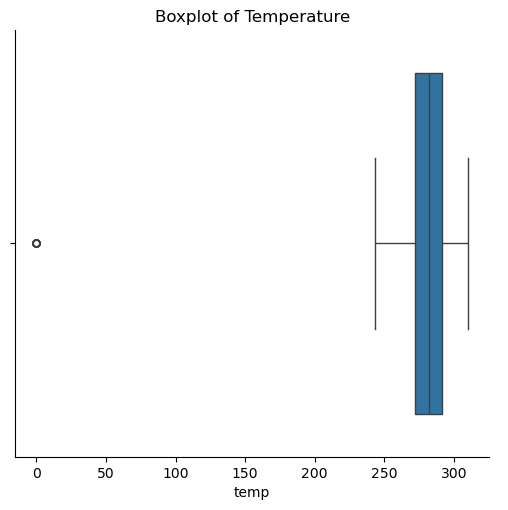

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
11898,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 03:00:00,361
11899,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 04:00:00,734
11900,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 05:00:00,2557
11901,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-01-31 06:00:00,5150
11946,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 03:00:00,291
11947,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 04:00:00,284
11948,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 05:00:00,434
11949,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 06:00:00,739
11950,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 07:00:00,962
11951,NaN,0.0,0.0,0.0,0,Clear,sky is clear,2014-02-02 08:00:00,1670


In [484]:
# boxplot of each numerical column
sns.catplot(data = df, x = 'temp',kind = 'box')
plt.title('Boxplot of Temperature')
plt.show()
getOutliers(df, 'temp')

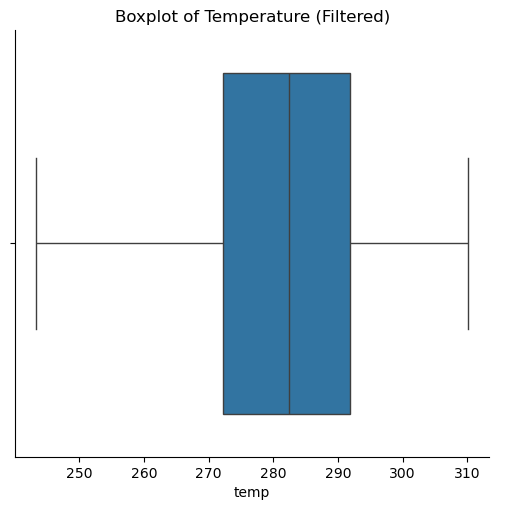

In [485]:
# Keep only the rows where the temperature is greater than 0,
# since a temperature of 0 kelvin is physically impossible and likely indicates a data entry error.
df = df[df['temp'] > 0]
sns.catplot(df, x = 'temp',kind = 'box')
plt.title('Boxplot of Temperature (Filtered)')
plt.show()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
24872,NaN,302.11,9831.30,0.0,75,Rain,very heavy rain,2016-07-11 17:00:00,5535
8247,NaN,289.10,55.63,0.0,68,Rain,very heavy rain,2013-08-07 02:00:00,315
7179,NaN,295.82,44.45,0.0,76,Rain,very heavy rain,2013-06-24 11:00:00,4802
25779,NaN,297.71,31.75,0.0,0,Rain,very heavy rain,2016-08-16 17:00:00,4913
10806,NaN,264.50,28.70,0.0,64,Rain,very heavy rain,2013-12-19 23:00:00,1190
...,...,...,...,...,...,...,...,...,...
14888,NaN,287.82,0.25,0.0,100,Rain,light rain,2014-06-04 06:00:00,5904
14876,NaN,295.45,0.25,0.0,1,Rain,light rain,2014-06-03 18:00:00,4678
14870,NaN,293.94,0.25,0.0,0,Rain,light rain,2014-06-03 11:00:00,4787
14859,NaN,290.90,0.25,0.0,1,Rain,light rain,2014-06-02 22:00:00,1761


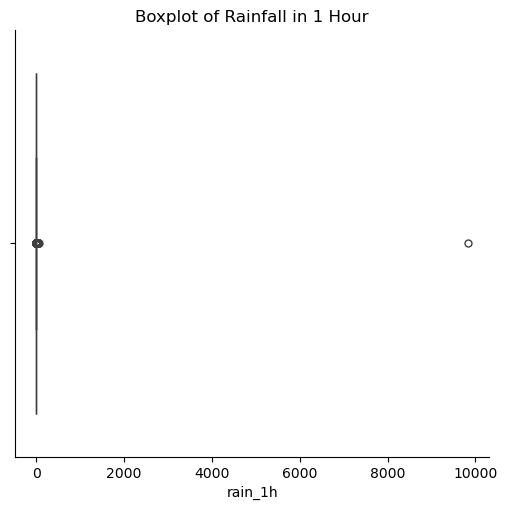

In [486]:
sns.catplot(data = df, x = 'rain_1h',kind = 'box')
plt.title('Boxplot of Rainfall in 1 Hour')
getOutliers(df, 'rain_1h').sort_values(by='rain_1h', ascending=False)

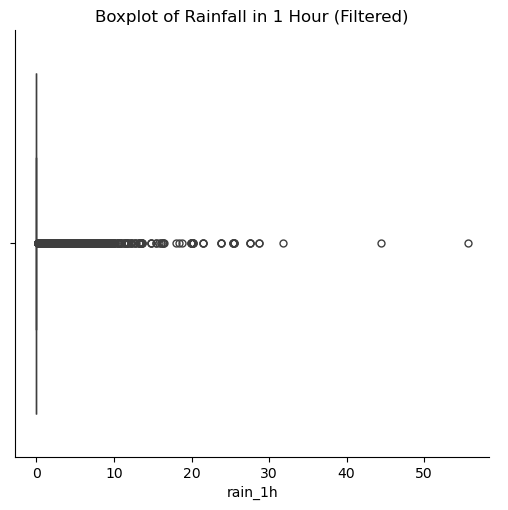

In [487]:
# Keep only the rows where the rainfall in 1 hour is less than 9831.30,
# since a rainfall of 9831.30 mm in 1 hour is physically impossible and likely indicates a data entry error.
df = df[df['rain_1h'] < 9831.30]

sns.catplot(data = df, x = 'rain_1h',kind = 'box')
plt.title('Boxplot of Rainfall in 1 Hour (Filtered)')
plt.show()

Text(0.5, 1.0, 'Boxplot of Traffic Volume')

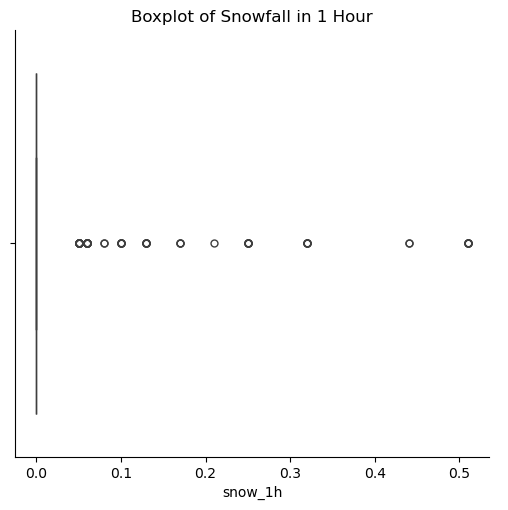

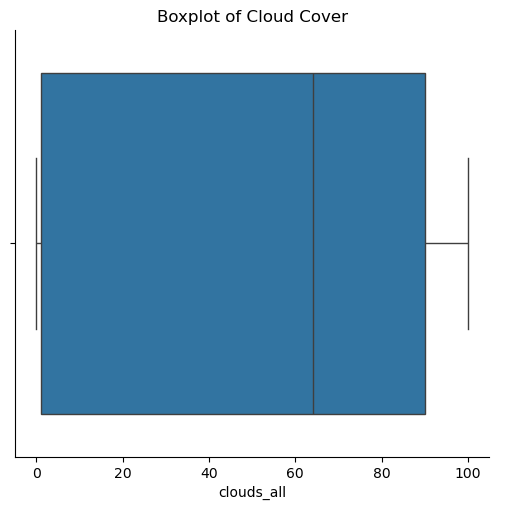

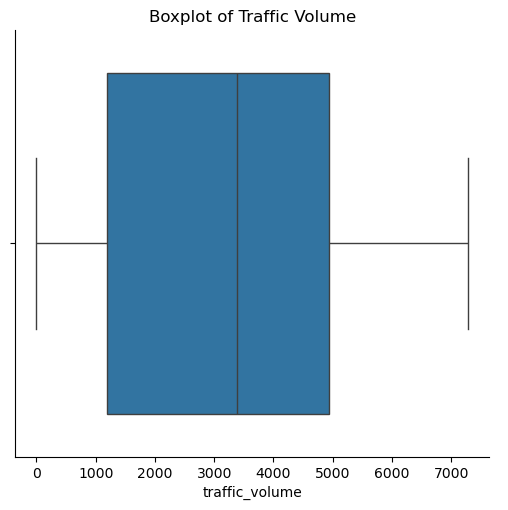

In [488]:

sns.catplot(data = df, x = 'snow_1h',kind = 'box')
plt.title('Boxplot of Snowfall in 1 Hour')

sns.catplot(df, x = 'clouds_all',kind = 'box')
plt.title('Boxplot of Cloud Cover')

sns.catplot(data = df, x = 'traffic_volume',kind = 'box')
plt.title('Boxplot of Traffic Volume')

In [489]:
df['holiday'].value_counts()

holiday
Labor Day                    7
Thanksgiving Day             6
Christmas Day                6
New Years Day                6
Martin Luther King Jr Day    6
Columbus Day                 5
Veterans Day                 5
Washingtons Birthday         5
Memorial Day                 5
Independence Day             5
State Fair                   5
Name: count, dtype: int64

In [490]:
df['weather_main'].value_counts()

weather_main
Clouds          15164
Clear           13381
Mist             5950
Rain             5671
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

In [491]:
df['weather_description'].value_counts()

weather_description
sky is clear                           11655
mist                                    5950
overcast clouds                         5081
broken clouds                           4666
scattered clouds                        3461
light rain                              3372
few clouds                              1956
light snow                              1946
Sky is Clear                            1726
moderate rain                           1664
haze                                    1360
light intensity drizzle                 1100
fog                                      912
proximity thunderstorm                   673
drizzle                                  651
heavy snow                               616
heavy intensity rain                     467
snow                                     293
proximity shower rain                    136
thunderstorm                             125
heavy intensity drizzle                   64
thunderstorm with heavy rain       

In [492]:
df['date_time'].value_counts()

date_time
2013-04-18 22:00:00    6
2013-05-19 10:00:00    6
2013-05-31 00:00:00    5
2013-12-03 13:00:00    5
2013-05-20 17:00:00    5
                      ..
2015-07-04 00:00:00    1
2015-07-04 10:00:00    1
2015-07-04 11:00:00    1
2015-07-04 12:00:00    1
2018-09-30 23:00:00    1
Name: count, Length: 40564, dtype: int64

In [493]:
df['date_time'] = pd.to_datetime(df['date_time'])
df['year'] = df['date_time'].dt.year 
df['month'] = df['date_time'].dt.month
df['dayOfWeek'] = df['date_time'].dt.dayofweek + 1 # 1 = Monday, 7 = Sunday
df['day'] = df['date_time'].dt.day
df['hour'] = df['date_time'].dt.hour + 1
df['isWeekend'] = df['date_time'].dt.dayofweek >= 6

In [494]:
df[['year', 'month', 'day', 'dayOfWeek', 'hour', 'isWeekend']].aggregate(['min', 'max'])

,year,month,day,dayOfWeek,hour,isWeekend
min,2012,1,1,1,1,False
max,2018,12,31,7,24,True


In [495]:
# pull each row that has a holiday and display the date_time, holiday, and traffic_volume columns and print to a csv file
df[df['holiday'].notna()][['month', 'day', 'year', 'holiday']].drop_duplicates()

,month,day,year,holiday
126,10,8,2012,Columbus Day
1123,11,12,2012,Veterans Day
1370,11,22,2012,Thanksgiving Day
2360,12,25,2012,Christmas Day
2559,1,1,2013,New Years Day
3697,2,18,2013,Washingtons Birthday
6430,5,27,2013,Memorial Day
7414,7,4,2013,Independence Day
8575,8,22,2013,State Fair
8742,9,2,2013,Labor Day


In [496]:
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume', 'year', 'month',
       'dayOfWeek', 'day', 'hour', 'isWeekend'],
      dtype='object')

In [497]:
# one hot encode holiday and weather_main columns
df = pd.get_dummies(df, columns=['holiday', 'weather_main'])


In [498]:
df.head()

,temp,rain_1h,snow_1h,clouds_all,weather_description,date_time,traffic_volume,year,month,dayOfWeek,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,288.28,0.0,0.0,40,scattered clouds,2012-10-02 09:00:00,5545,2012,10,2,...,True,False,False,False,False,False,False,False,False,False
1,289.36,0.0,0.0,75,broken clouds,2012-10-02 10:00:00,4516,2012,10,2,...,True,False,False,False,False,False,False,False,False,False
2,289.58,0.0,0.0,90,overcast clouds,2012-10-02 11:00:00,4767,2012,10,2,...,True,False,False,False,False,False,False,False,False,False
3,290.13,0.0,0.0,90,overcast clouds,2012-10-02 12:00:00,5026,2012,10,2,...,True,False,False,False,False,False,False,False,False,False
4,291.14,0.0,0.0,75,broken clouds,2012-10-02 13:00:00,4918,2012,10,2,...,True,False,False,False,False,False,False,False,False,False


In [499]:
df.describe(include='all')

,temp,rain_1h,snow_1h,clouds_all,weather_description,date_time,traffic_volume,year,month,dayOfWeek,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
count,48193.000000,48193.000000,48193.000000,48193.000000,48193,48193,48193.000000,48193.000000,48193.000000,48193.000000,...,48193,48193,48193,48193,48193,48193,48193,48193,48193,48193
unique,NaN,NaN,NaN,NaN,38,NaN,NaN,NaN,NaN,NaN,...,2,2,2,2,2,2,2,2,2,2
top,NaN,NaN,NaN,NaN,sky is clear,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
freq,NaN,NaN,NaN,NaN,11655,NaN,NaN,NaN,NaN,NaN,...,33029,46372,47281,46833,42243,42522,48173,45317,48189,47159
mean,281.263786,0.130342,0.000222,49.371942,NaN,2016-01-05 14:10:43.238644480,3260.174029,2015.512730,6.507045,3.984583,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,243.390000,0.000000,0.000000,0.000000,NaN,2012-10-02 09:00:00,0.000000,2012.000000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,272.180000,0.000000,0.000000,1.000000,NaN,2014-02-06 19:00:00,1194.000000,2014.000000,4.000000,2.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,282.460000,0.000000,0.000000,64.000000,NaN,2016-06-11 08:00:00,3380.000000,2016.000000,7.000000,4.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,291.810000,0.000000,0.000000,90.000000,NaN,2017-08-11 07:00:00,4933.000000,2017.000000,9.000000,6.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,310.070000,55.630000,0.510000,100.000000,NaN,2018-09-30 23:00:00,7280.000000,2018.000000,12.000000,7.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


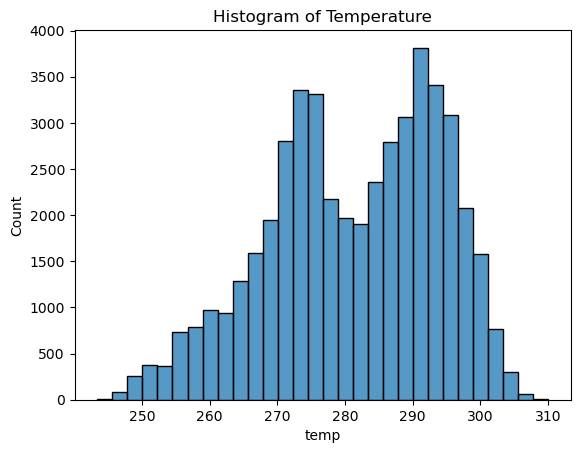

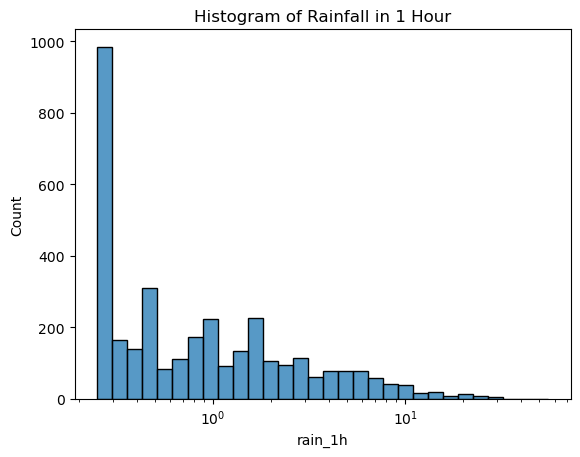

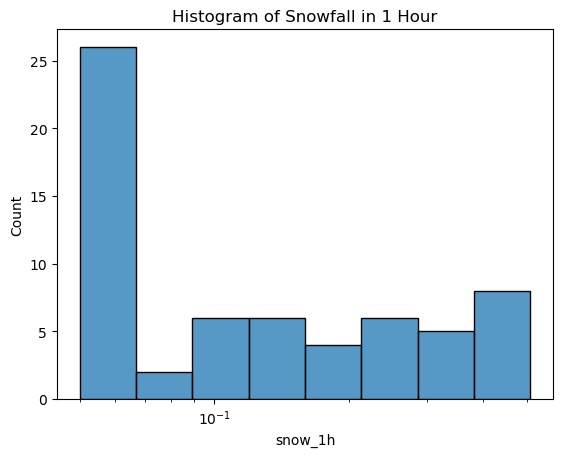

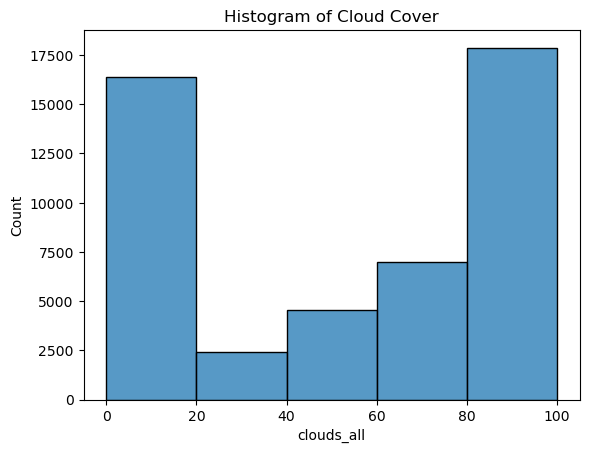

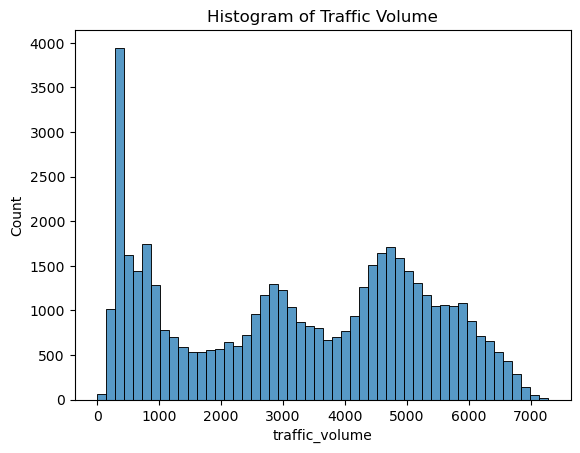

In [500]:
# plot histograms of continuous variables
sns.histplot(data=df, x='temp', bins=30)
plt.title('Histogram of Temperature')
plt.show()

sns.histplot(data=df, x='rain_1h', bins=30, log_scale=True)
plt.title('Histogram of Rainfall in 1 Hour')
plt.show()

sns.histplot(data=df, x='snow_1h', bins=8, log_scale=True)
plt.title('Histogram of Snowfall in 1 Hour')
plt.show()

sns.histplot(data=df, x='clouds_all', bins=5)
plt.title('Histogram of Cloud Cover')
plt.show()

sns.histplot(data=df, x='traffic_volume', bins=50)
plt.title('Histogram of Traffic Volume')
plt.show()

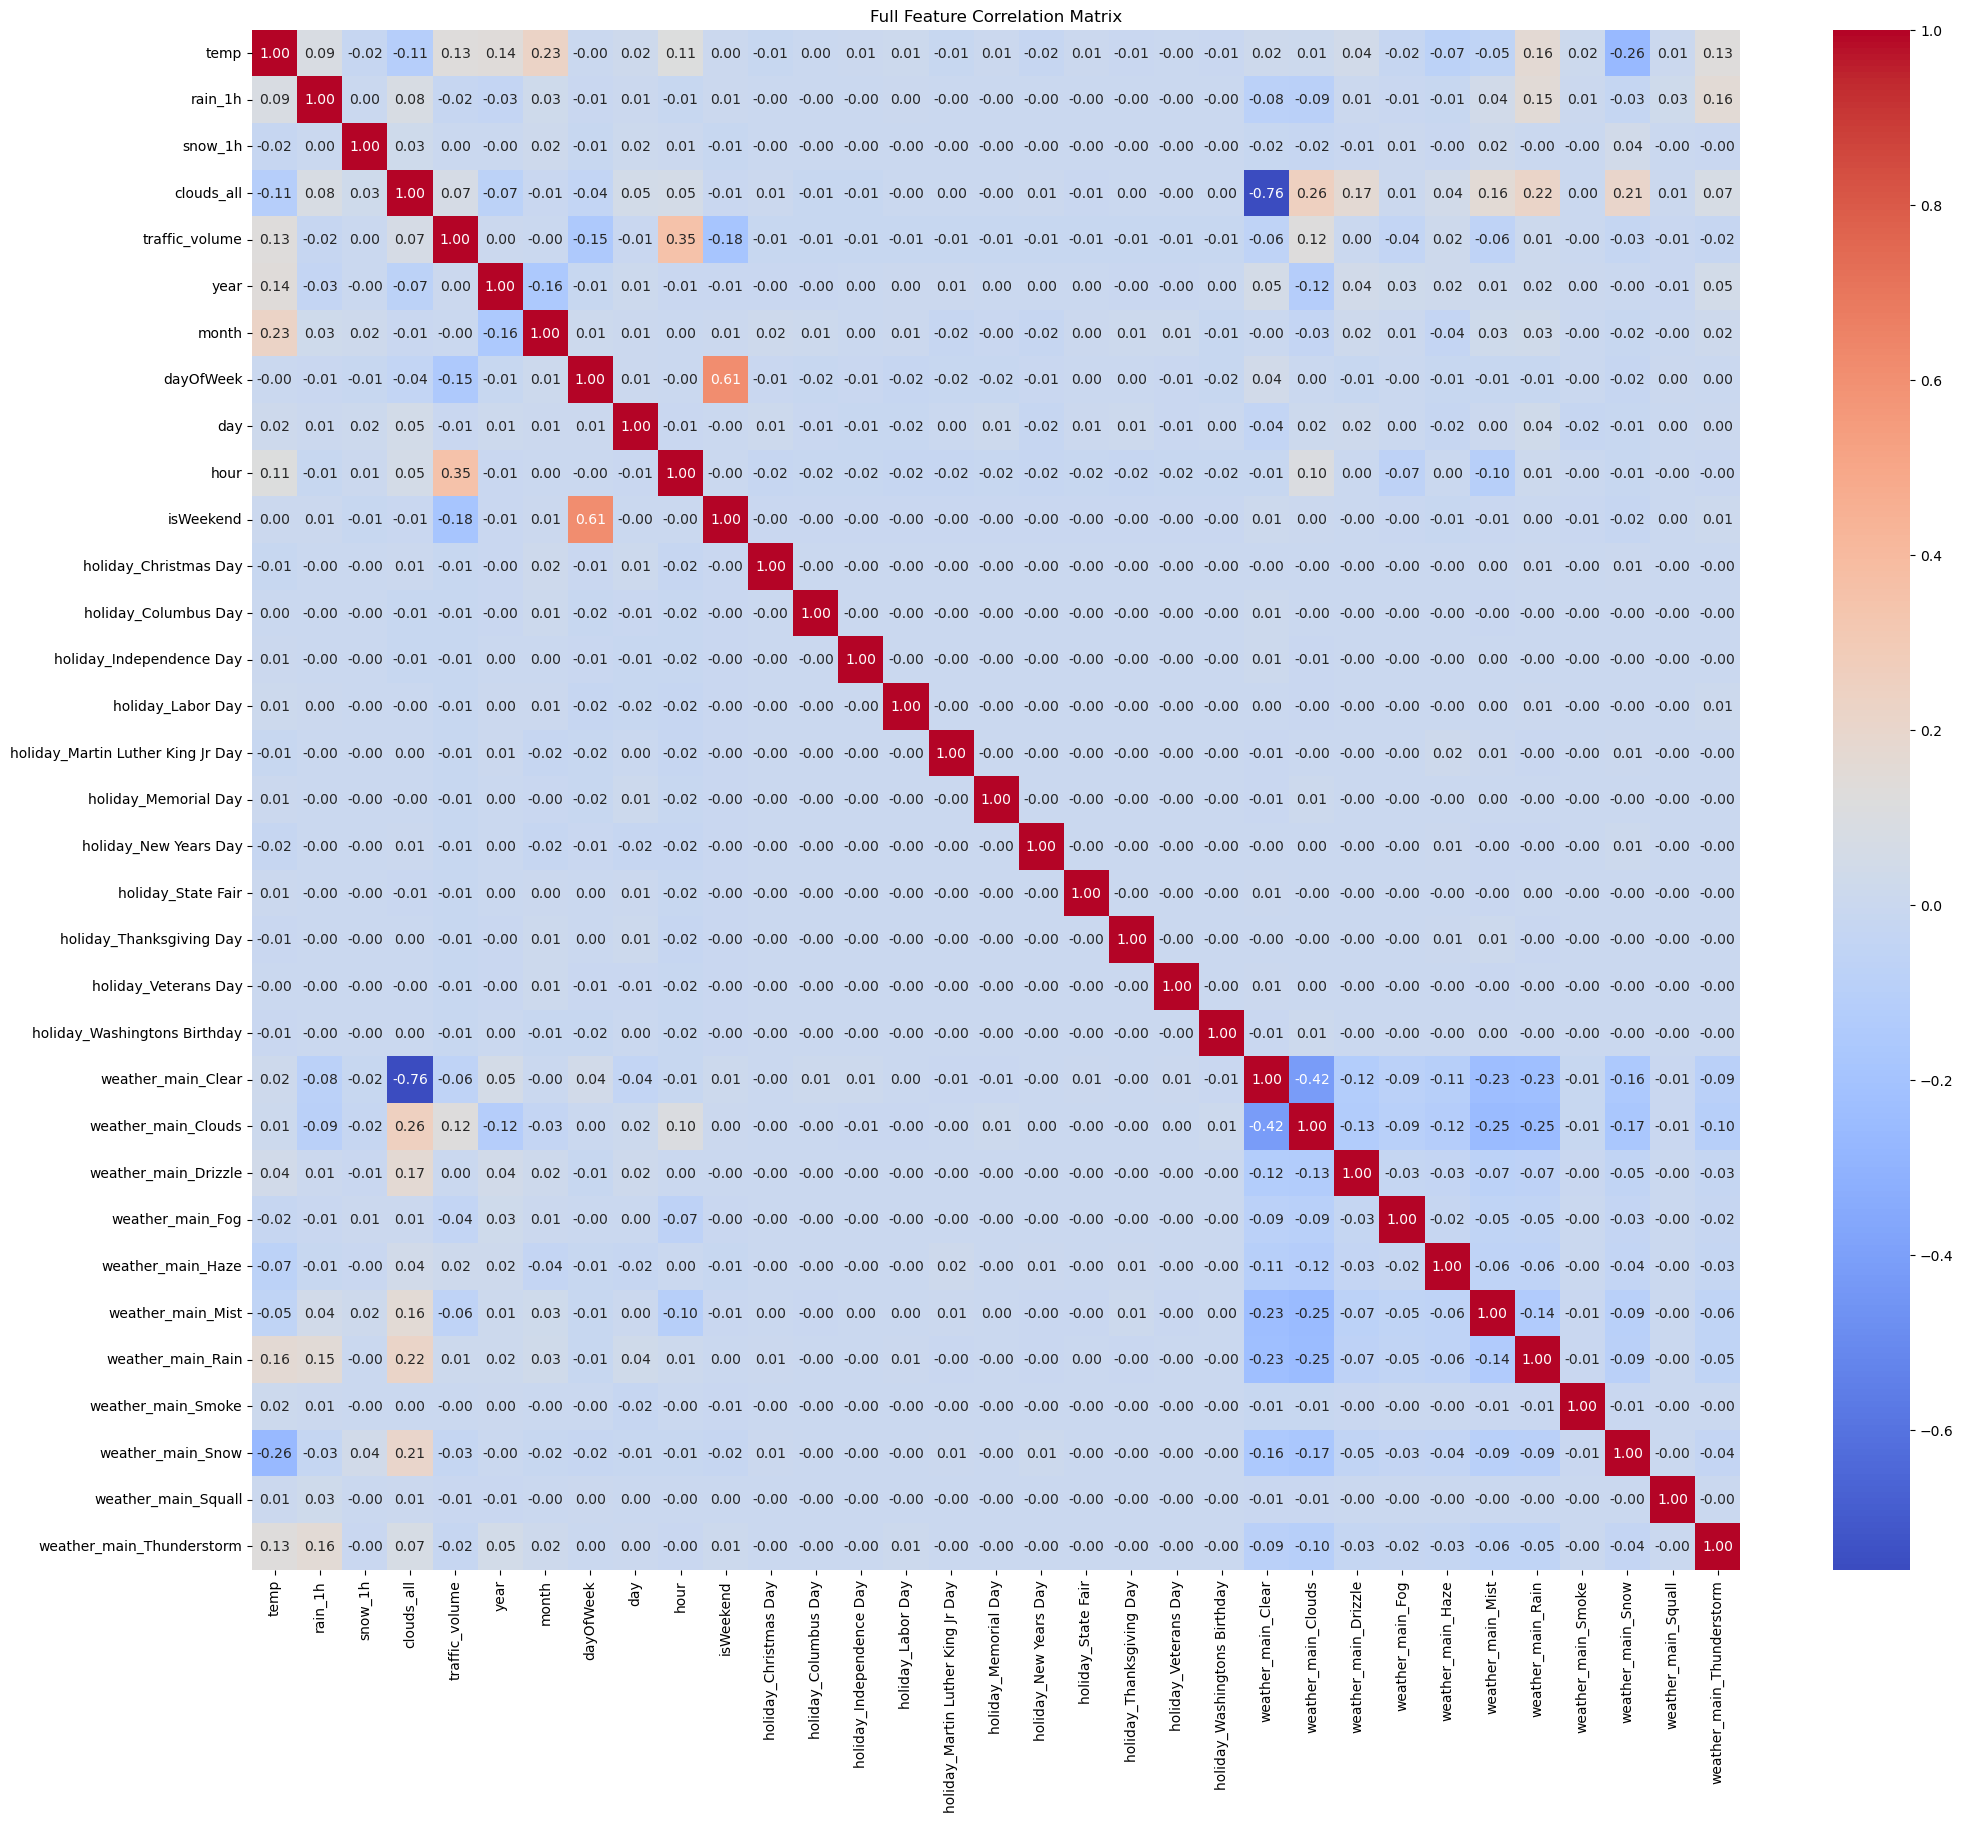

In [501]:
df = df.drop(columns=['date_time', 'weather_description'])
plt.figure(figsize=(24, 20))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Full Feature Correlation Matrix")
plt.show()

In [502]:
df.drop(columns=['dayOfWeek', 'weather_main_Clear', 'year', 'month', 'day', 'weather_main_Smoke', 'weather_main_Haze', 'weather_main_Squall', 'weather_main_Mist', 'weather_main_Fog', 'weather_main_Drizzle', 'weather_main_Thunderstorm'])
# keep: hour, isWeekend, temp, rain_1h, snow_1h, clouds_all, traffic_volume, holiday_None, weather_main_Clouds, weather_main_Rain, weather_main_Snow, all other holidays

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,isWeekend,holiday_Christmas Day,holiday_Columbus Day,holiday_Independence Day,...,holiday_Martin Luther King Jr Day,holiday_Memorial Day,holiday_New Years Day,holiday_State Fair,holiday_Thanksgiving Day,holiday_Veterans Day,holiday_Washingtons Birthday,weather_main_Clouds,weather_main_Rain,weather_main_Snow
0,288.28,0.0,0.0,40,5545,10,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,289.36,0.0,0.0,75,4516,11,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,289.58,0.0,0.0,90,4767,12,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,290.13,0.0,0.0,90,5026,13,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,291.14,0.0,0.0,75,4918,14,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48199,283.45,0.0,0.0,75,3543,20,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
48200,282.76,0.0,0.0,90,2781,21,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
48201,282.73,0.0,0.0,90,2159,22,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
48202,282.09,0.0,0.0,90,1450,23,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [503]:
# split the data into training and testing sets
X = df.drop(columns=['traffic_volume'])
y = df['traffic_volume']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [504]:
# standardize and normalize using StandardScaler and MinMaxScaler
# 1. Define ONLY the continuous features that need scaling
continuous_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour']

# 2. Initialize the scaler
scaler = StandardScaler()

# 3. Fit the scaler to the training data AND transform it in one step
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])

# 4. Transform the test data using the parameters learned from the training set
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

In [505]:
X_train.columns

Index(['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'year', 'month',
       'dayOfWeek', 'day', 'hour', 'isWeekend', 'holiday_Christmas Day',
       'holiday_Columbus Day', 'holiday_Independence Day', 'holiday_Labor Day',
       'holiday_Martin Luther King Jr Day', 'holiday_Memorial Day',
       'holiday_New Years Day', 'holiday_State Fair',
       'holiday_Thanksgiving Day', 'holiday_Veterans Day',
       'holiday_Washingtons Birthday', 'weather_main_Clear',
       'weather_main_Clouds', 'weather_main_Drizzle', 'weather_main_Fog',
       'weather_main_Haze', 'weather_main_Mist', 'weather_main_Rain',
       'weather_main_Smoke', 'weather_main_Snow', 'weather_main_Squall',
       'weather_main_Thunderstorm'],
      dtype='object')